In [1]:
import pandas as pd

def preprocess_market_data(file_path):
    # Load file
    df = pd.read_csv(file_path)

    # Keep only necessary columns
    df = df[["Arrival_Date", "Modal_Price"]]

    # Convert to datetime
    df["Arrival_Date"] = pd.to_datetime(df["Arrival_Date"], dayfirst=True)

    # Sort by date
    df = df.sort_values("Arrival_Date")

    # Handle duplicate dates (take average)
    df = df.groupby("Arrival_Date").mean()

    # Set daily frequency
    df = df.asfreq("D")

    # Interpolate missing prices
    df["Modal_Price"] = df["Modal_Price"].interpolate()

    # Convert to monthly average
    monthly_price = df["Modal_Price"].resample("M").mean()

    return monthly_price


In [2]:
coffee_price = preprocess_market_data("/content/datas/coffee.csv")

coffee_price.head()


/tmp/ipython-input-3179309854.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_price = df["Modal_Price"].resample("M").mean()


,Modal_Price
Arrival_Date,
2020-01-31,10558.602151
2020-02-29,10252.298851
2020-03-31,10273.118280
2020-04-30,11016.944444
2020-05-31,10904.569892


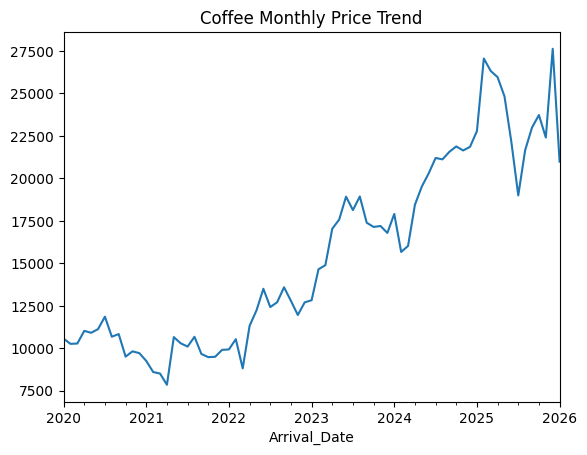

In [3]:
import matplotlib.pyplot as plt

coffee_price.plot(title="Coffee Monthly Price Trend")
plt.show()


In [4]:
coffee_price.to_csv("coffee_monthly_preprocessed.csv")


In [5]:
coffee_price.head()

,Modal_Price
Arrival_Date,
2020-01-31,10558.602151
2020-02-29,10252.298851
2020-03-31,10273.118280
2020-04-30,11016.944444
2020-05-31,10904.569892


In [7]:
banana_price = preprocess_market_data("/content/datas/banana.csv")
ginger_price = preprocess_market_data("/content/datas/ginger.csv")
pepper_price = preprocess_market_data("/content/datas/pepper.csv")
tapioca_price = preprocess_market_data("/content/datas/tapioca.csv")
paddy_price = preprocess_market_data("/content/datas/paddy.csv")
cardomom_price = preprocess_market_data("/content/datas/cardomom.csv")


/tmp/ipython-input-3179309854.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_price = df["Modal_Price"].resample("M").mean()
/tmp/ipython-input-3179309854.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_price = df["Modal_Price"].resample("M").mean()
/tmp/ipython-input-3179309854.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_price = df["Modal_Price"].resample("M").mean()
/tmp/ipython-input-3179309854.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_price = df["Modal_Price"].resample("M").mean()
/tmp/ipython-input-3179309854.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_price = df["Modal_Price"].resample("M").mean()
/tmp/ipython-input-3179309854.py:26

In [8]:
tapioca_price.head()


,Modal_Price
Arrival_Date,
2020-05-31,1540.659341
2020-06-30,1536.428571
2020-07-31,1580.000000
2020-08-31,1624.285714
2020-09-30,1667.857143


In [10]:
coffee_price.to_csv("coffee_pre.csv")

banana_price.to_csv("banana_pre.csv")
ginger_price.to_csv("ginger_pre.csv")
pepper_price.to_csv("pepper_pre.csv")
tapioca_price.to_csv("tapioca_pre.csv")
paddy_price.to_csv("paddy_pre.csv")
cardomom_price.to_csv("cardomom_pre.csv")



In [11]:
coffee_price.tail()

,Modal_Price
Arrival_Date,
2025-09-30,22995.833333
2025-10-31,23725.000000
2025-11-30,22403.069444
2025-12-31,27627.553763
2026-01-31,20979.310345


In [12]:
files = {
    "coffee": "/content/coffee_pre.csv",
    "banana": "/content/banana_pre.csv",
    "ginger": "/content/ginger_pre.csv",
    "pepper": "/content/pepper_pre.csv",
    "paddy": "/content/paddy_pre.csv",
    "tapioca": "/content/tapioca_pre.csv",
    "cardomom": "/content/cardomom_pre.csv"
}

for name, file in files.items():
    df = pd.read_csv(file, index_col=0, parse_dates=True)
    print(name, "→", len(df))


coffee → 73
banana → 71
ginger → 71
pepper → 119
paddy → 3
tapioca → 45
cardomom → 10


In [13]:
import pandas as pd

coffee = pd.read_csv("/content/coffee_pre.csv", index_col=0, parse_dates=True)

coffee = coffee.squeeze()   # converts to Series
coffee.head()


,Modal_Price
Arrival_Date,
2020-01-31,10558.602151
2020-02-29,10252.298851
2020-03-31,10273.118280
2020-04-30,11016.944444
2020-05-31,10904.569892


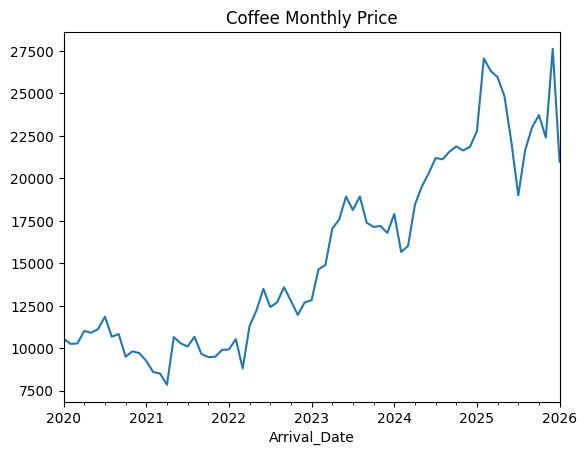

In [14]:
import matplotlib.pyplot as plt

coffee.plot(title="Coffee Monthly Price")
plt.show()


In [15]:
files = {
    "Coffee": "/content/coffee_pre.csv",
    "Banana": "/content/banana_pre.csv",
    "Ginger": "/content/ginger_pre.csv",
    "Pepper": "/content/pepper_pre.csv"
}


In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarima_trend(series, steps=6):
    model = SARIMAX(
        series,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    results = model.fit(disp=False)
    forecast = results.forecast(steps=steps)

    recent_avg = series[-3:].mean()
    future_avg = forecast.mean()

    return "UP" if future_avg > recent_avg else "DOWN"


In [17]:
import pandas as pd

market_trend = {}

for crop, file in files.items():
    df = pd.read_csv(file, index_col=0, parse_dates=True)
    series = df.squeeze()

    trend = sarima_trend(series)
    market_trend[crop] = trend

market_trend


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so 

{'Coffee': 'UP', 'Banana': 'UP', 'Ginger': 'UP', 'Pepper': 'UP'}

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


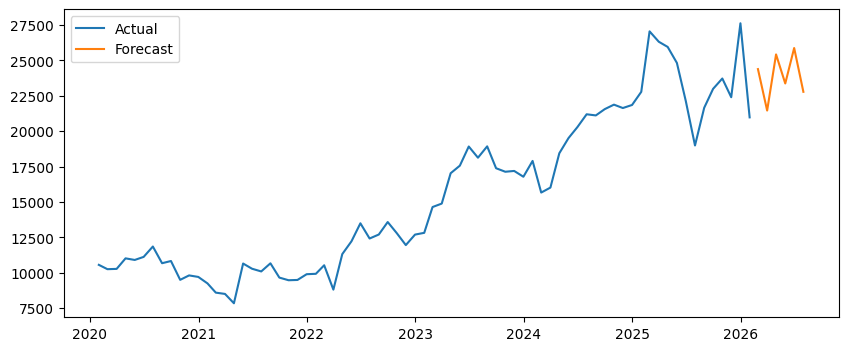

In [19]:
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Re-run the SARIMAX model for coffee to get the forecast variable
model = SARIMAX(
    coffee,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit(disp=False)
forecast = results.forecast(steps=6)

plt.figure(figsize=(10,4))
plt.plot(coffee, label="Actual")
plt.plot(forecast.index, forecast, label="Forecast")
plt.legend()
plt.show()

In [21]:
print("Recent Avg:", coffee[-3:].mean())
print("Forecast Avg:", forecast.mean())


Recent Avg: 23669.9778509043
Forecast Avg: 23886.092793567474


In [44]:
def sarima_trend(series, steps=6):
    model = SARIMAX(
        series,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    results = model.fit(disp=False)
    forecast = results.forecast(steps=steps)

    recent_avg = series[-3:].mean()
    future_avg = forecast.mean()

    percent_change = ((future_avg - recent_avg) / recent_avg) * 100

    if percent_change > 5:
        direction = "UP"
    elif percent_change < -5:
        direction = "DOWN"
    else:
        direction = "STABLE"


    return direction, round(percent_change, 2)


In [25]:
market_trend = {}

for crop, file in files.items():
    df = pd.read_csv(file, index_col=0, parse_dates=True)
    series = df.squeeze()

    direction, percent = sarima_trend(series)

    market_trend[crop] = {
        "direction": direction,
        "percent_change": percent
    }

market_trend


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so 

{'Coffee': {'direction': 'UP', 'percent_change': np.float64(0.91)},
 'Banana': {'direction': 'UP', 'percent_change': np.float64(48.5)},
 'Ginger': {'direction': 'UP', 'percent_change': np.float64(9.27)},
 'Pepper': {'direction': 'UP', 'percent_change': np.float64(4.1)}}

In [26]:
banana = pd.read_csv("banana_pre.csv", index_col=0, parse_dates=True).squeeze()

print("Recent 3 Months:")
print(banana[-3:])

print("\nForecast:")
print(results.forecast(steps=6))


Recent 3 Months:
Arrival_Date
2025-09-30    2120.241249
2025-10-31    1833.817509
2025-11-30    2060.666667
Name: Modal_Price, dtype: float64

Forecast:
2026-02-28    24390.612173
2026-03-31    21460.277214
2026-04-30    25427.297652
2026-05-31    23374.944991
2026-06-30    25879.367011
2026-07-31    22784.057720
Freq: ME, Name: predicted_mean, dtype: float64


In [27]:
banana.head()
banana.tail()


,Modal_Price
Arrival_Date,
2025-07-31,2753.578120
2025-08-31,2590.081693
2025-09-30,2120.241249
2025-10-31,1833.817509
2025-11-30,2060.666667


In [28]:
banana.max()
banana.min()


1441.9354838709678

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


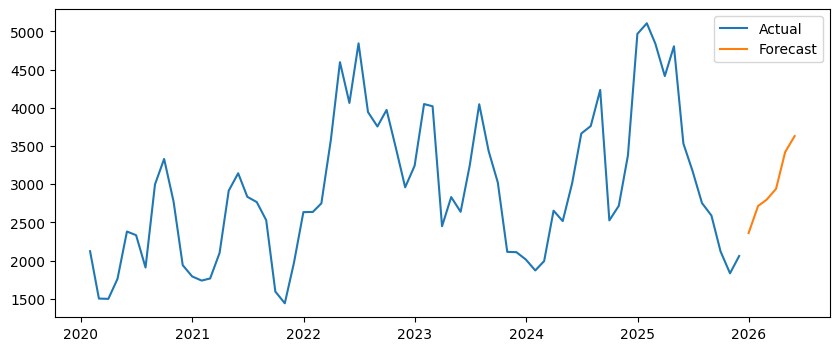

In [29]:
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Re-run the SARIMAX model for coffee to get the forecast variable
model = SARIMAX(
    banana,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit(disp=False)
forecast = results.forecast(steps=6)

plt.figure(figsize=(10,4))
plt.plot(banana, label="Actual")
plt.plot(forecast.index, forecast, label="Forecast")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarima_trend(series, steps=6, threshold=5):
    model = SARIMAX(
        series,
        order=(1,1,0),
        seasonal_order=(0,1,1,12)
    )

    results = model.fit(disp=False)
    forecast = results.forecast(steps=steps)

    # Compare last 6 months vs next 3 months
    recent_avg = series[-6:].mean()
    future_avg = forecast[:3].mean()

    percent_change = ((future_avg - recent_avg) / recent_avg) * 100
    percent_change = float(round(percent_change, 2))

    # Classification with threshold
    if percent_change > threshold:
        direction = "UP"
    elif percent_change < -threshold:
        direction = "DOWN"
    else:
        direction = "STABLE"

    return direction, percent_change


In [48]:
market_trend = {}

for crop, file in files.items():
    df = pd.read_csv(file, index_col=0, parse_dates=True)
    series = df.squeeze()

    direction, percent = sarima_trend(series)

    market_trend[crop] = {
        "direction": direction,
        "percent_change": percent
    }

market_trend


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

{'Coffee': {'direction': 'STABLE', 'percent_change': 4.6},
 'Banana': {'direction': 'UP', 'percent_change': 8.74},
 'Ginger': {'direction': 'UP', 'percent_change': 17.46},
 'Pepper': {'direction': 'STABLE', 'percent_change': 4.11}}

In [53]:
def simple_trend(series, threshold=5):
    recent_avg = series[-6:].mean()
    overall_avg = series[-12:].mean()

    percent_change = ((recent_avg - overall_avg) / overall_avg) * 100
    percent_change = float(round(percent_change, 2))

    if percent_change > threshold:
        direction = "UP"
    elif percent_change < -threshold:
        direction = "DOWN"
    else:
        direction = "STABLE"

    return direction, percent_change


In [54]:
tapioca = pd.read_csv("tapioca_pre.csv", index_col=0, parse_dates=True).squeeze()

simple_trend(tapioca)


('UP', 25.08)

In [55]:
market_trend = {}

# SARIMA crops
sarima_files = {
    "Coffee": "coffee_pre.csv",
    "Banana": "banana_pre.csv",
    "Ginger": "ginger_pre.csv",
    "Pepper": "pepper_pre.csv"
}

for crop, file in sarima_files.items():
    df = pd.read_csv(file, index_col=0, parse_dates=True).squeeze()
    direction, percent = sarima_trend(df)
    market_trend[crop] = {
        "direction": direction,
        "percent_change": percent
    }

# Tapioca (simple method)
tapioca = pd.read_csv("tapioca_pre.csv", index_col=0, parse_dates=True).squeeze()
direction, percent = simple_trend(tapioca)
market_trend["Tapioca"] = {
    "direction": direction,
    "percent_change": percent
}

market_trend


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

{'Coffee': {'direction': 'STABLE', 'percent_change': 4.6},
 'Banana': {'direction': 'UP', 'percent_change': 8.74},
 'Ginger': {'direction': 'UP', 'percent_change': 17.46},
 'Pepper': {'direction': 'STABLE', 'percent_change': 4.11},
 'Tapioca': {'direction': 'UP', 'percent_change': 25.08}}

In [ ]:
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

def plot_forecast(series, crop_name, steps=6):
    model = SARIMAX(
        series,
        order=(1,1,0),
        seasonal_order=(0,1,1,12)
    )

    results = model.fit(disp=False)
    forecast = results.forecast(steps=steps)

    plt.figure(figsize=(10,5))

    # Historical data
    plt.plot(series, label="Historical", color="blue")

    # Forecast
    forecast_index = pd.date_range(
        start=series.index[-1],
        periods=steps+1,
        freq="M"
    )[1:]

    plt.plot(forecast_index, forecast,
             label="Forecast",
             color="red",
             linestyle="--")

    plt.title(f"{crop_name} Price Forecast")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)

    plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-1493986805.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(


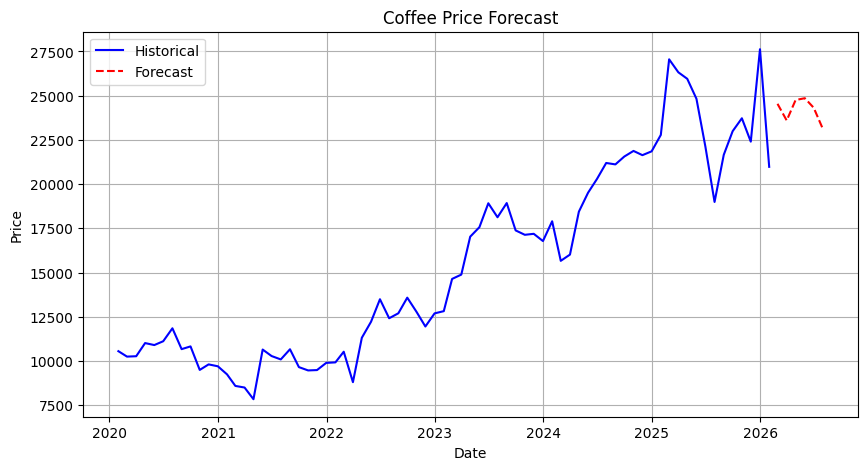

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-1493986805.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(


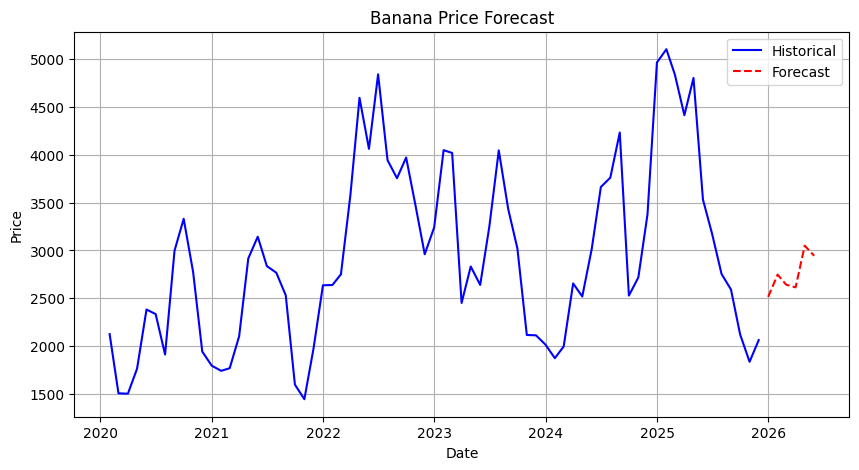

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/tmp/ipython-input-1493986805.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(


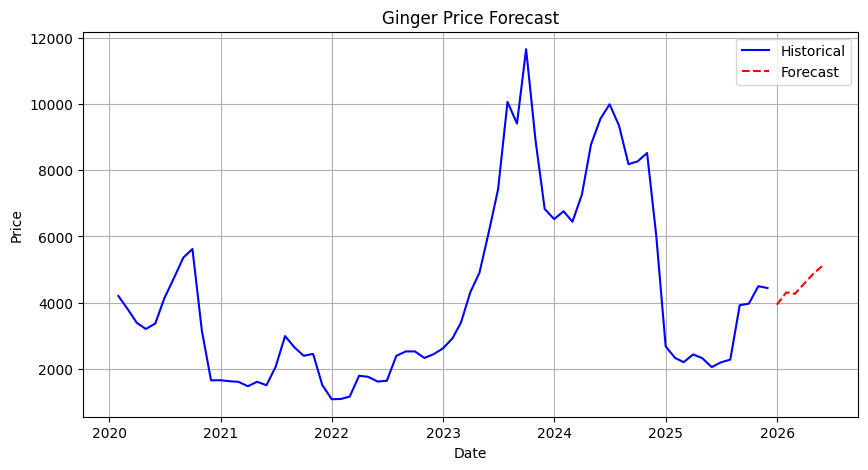

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-1493986805.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(


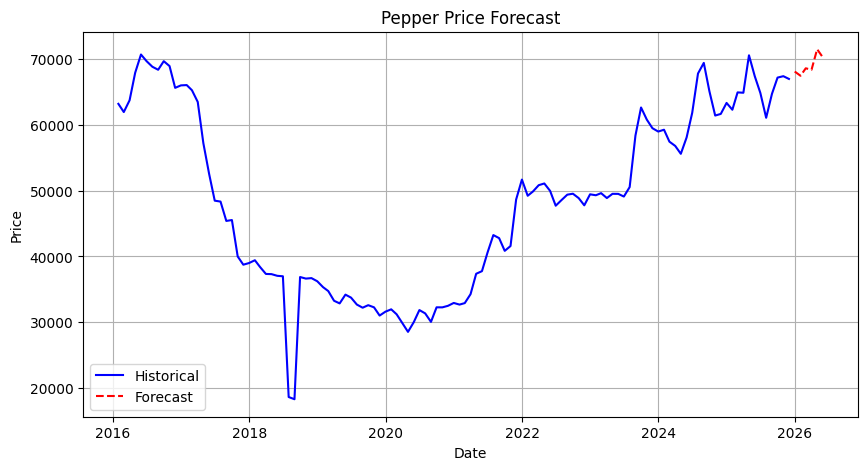

In [57]:
coffee = pd.read_csv("coffee_pre.csv", index_col=0, parse_dates=True).squeeze()
plot_forecast(coffee, "Coffee")

banana = pd.read_csv("banana_pre.csv", index_col=0, parse_dates=True).squeeze()
plot_forecast(banana, "Banana")

ginger = pd.read_csv("ginger_pre.csv", index_col=0, parse_dates=True).squeeze()
plot_forecast(ginger, "Ginger")

pepper = pd.read_csv("pepper_pre.csv", index_col=0, parse_dates=True).squeeze()
plot_forecast(pepper, "Pepper")


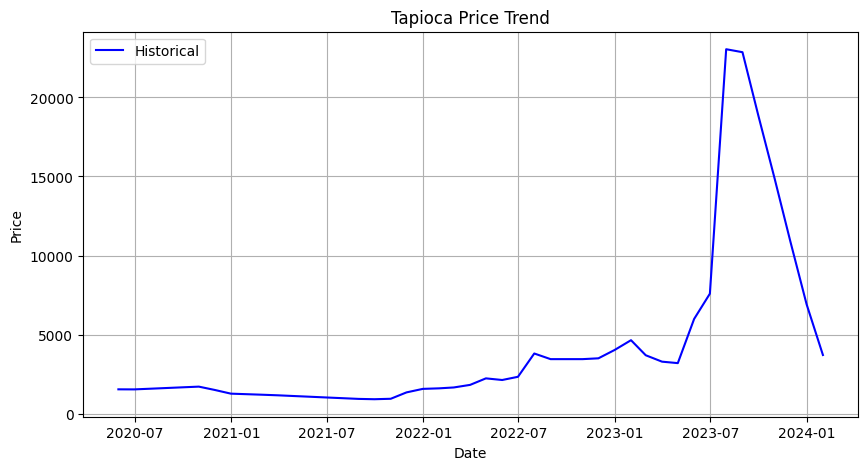

In [58]:
tapioca = pd.read_csv("tapioca_pre.csv", index_col=0, parse_dates=True).squeeze()

plt.figure(figsize=(10,5))
plt.plot(tapioca, label="Historical", color="blue")
plt.title("Tapioca Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

tapioca = pd.read_csv("tapioca_pre.csv", index_col=0, parse_dates=True).squeeze()


In [60]:
t = np.arange(len(tapioca)).reshape(-1,1)
y = tapioca.values
model = LinearRegression()
model.fit(t, y)
future_t = np.arange(len(tapioca), len(tapioca)+6).reshape(-1,1)
forecast = model.predict(future_t)


/tmp/ipython-input-1619657105.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(


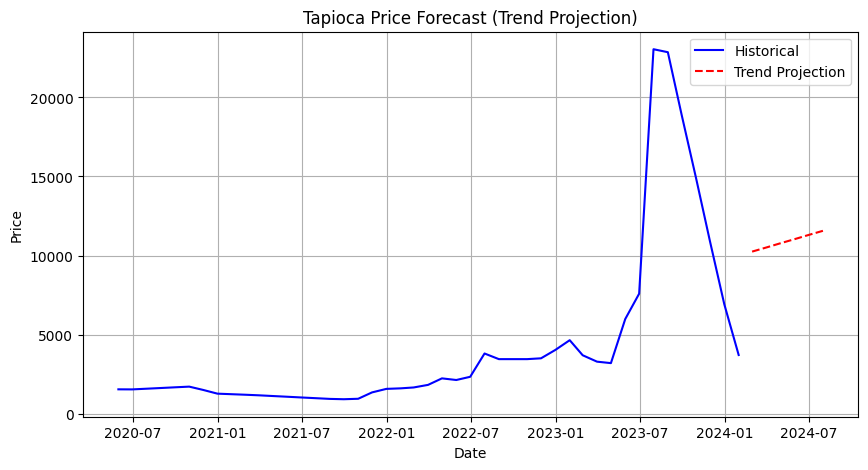

In [61]:
plt.figure(figsize=(10,5))

# Historical
plt.plot(tapioca.index, tapioca.values, label="Historical", color="blue")

# Forecast index
future_index = pd.date_range(
    start=tapioca.index[-1],
    periods=7,
    freq="M"
)[1:]

plt.plot(future_index, forecast,
         label="Trend Projection",
         color="red",
         linestyle="--")

plt.title("Tapioca Price Forecast (Trend Projection)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


In [62]:
import json
with open("market_trend.json", "w") as f:
    json.dump(market_trend, f)
